# Planes auto-editables: lazo abierto vs. replanificación

**Proyecto final — Inteligencia Artificial: Representación y Solución de Problemas (32310004)**
Universidad del Rosario

> ¿Bajo qué condiciones del entorno un agente que reescribe su propio plan supera a uno con
> plan estático, y a partir de qué costo de reescritura la ventaja se invierte?

Este cuaderno es la lectura de los resultados. El racional está en
[`docs/00-rationale.md`](docs/00-rationale.md), el diccionario conceptual en
[`docs/01-mapping.md`](docs/01-mapping.md) y la especificación del experimento en
[`docs/02-design.md`](docs/02-design.md). El análisis vive en `analysis.py`; aquí solo se
llama y se interpreta.

## 1. De dónde sale la pregunta

La pregunta no empieza en el curso: empieza en **OASys**, un motor de ejecución agéntica en
Rust donde un agente LLM puede leer y reescribir el programa que lo está ejecutando, mediante
dos herramientas — `readBook` (modo `Allow`) y `editBook` (modo `Ask`).

Esa capacidad existe pero **nunca se midió**, y tres decisiones de diseño están resueltas por
intuición:

| Decisión | Estado en el sistema real |
|---|---|
| Cuándo aplicar una edición | `run=hot` declarado en el DSL y **no implementado**: todo corre en frío sobre un *snapshot*, así que la edición solo surte efecto en la corrida siguiente |
| Cuántas veces deliberar | `const MAX_ITER: usize = 5;` — cinco, sin justificación derivada |
| Quién autoriza | `editBook` en modo `Ask`: **un humano** es el único freno contra un ciclo de reescrituras improductivas |

Al leer Russell & Norvig con OASys en la cabeza, resulta que el sistema reinventó piezas
clásicas: el Book es un **plan jerárquico**, `readBook` es **monitoreo de ejecución**,
`editBook` es **replanificación**, el set `ignore` es **observabilidad parcial**, y `cold` vs
`hot` es exactamente **lazo abierto vs. lazo cerrado** (R&N §11.5). La tabla completa, con
cita al archivo Rust y a la sección de R&N, está en [`docs/01-mapping.md`](docs/01-mapping.md).

Este trabajo modela esa semántica en MESA y mide la frontera.

In [1]:
from pathlib import Path
import sys

# El paquete se usa como módulo de primer nivel: `project/` va en la ruta, no se cuelga de
# `project/__init__.py`, que reexporta mesa.examples y rompe en Mesa 3.5.1 (ver README).
raiz = Path.cwd()
while not (raiz / "project").is_dir() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz / "project"))

from oasys_abm import analysis as an  # noqa: E402
from oasys_abm.agents import Policy  # noqa: E402

print("políticas:", ", ".join(str(p) for p in Policy))

políticas: REFLEX, MODEL_BASED, OPEN_LOOP, COLD_RESTART, CLOSED_LOOP, GOVERNED


## 2. El entorno de tarea (PEAS)

| Componente | Especificación |
|---|---|
| **P** — Rendimiento | Recursos entregados en la base antes de `T_max`, penalizado por el tiempo dedicado a deliberar |
| **E** — Entorno | Retícula 15×15 de von Neumann con obstáculos fijos; 8 recursos que se desplazan; base en posición fija |
| **A** — Actuadores | `GOTO`, `PICK`, `DELIVER` y **`DELIBERAR`**, que consume `c` ticks y produce un plan nuevo |
| **S** — Sensores | Contenido de las celdas dentro del radio `r`. Fuera de `r`, solo la creencia |

Clasificación (R&N §2.3.2): **parcialmente observable, estocástico, secuencial, dinámico,
discreto, de un agente**.

La decisión de modelado central es tratar **`DELIBERAR` como un actuador más**: pensar ocupa
ticks del reloj, y el mundo sigue moviéndose mientras el agente piensa. Sin eso no hay costo
que medir y la pregunta se vuelve trivial. De ahí se sigue la segunda decisión: *el plan que
produce una deliberación se calcula con el mundo tal como estaba cuando la deliberación
empezó*. Si el mundo se movió, el plan nace desactualizado.

### Las seis arquitecturas

| Política | R&N | OASys |
|---|---|---|
| `REFLEX` | §2.4.2 reflejo simple | — (línea base) |
| `MODEL_BASED` | §2.4.3 reflejo basado en modelo | estado en disco (`state.json`) |
| `OPEN_LOOP` | §2.4.4 basado en objetivos, lazo abierto | `cold` **sin** `editBook` |
| `COLD_RESTART` | lazo abierto con reinicio | `cold` **con** `editBook` — lo que el sistema hace hoy |
| `CLOSED_LOOP` | §11.5.3 planeación en línea | `run=hot` (no implementado) |
| `GOVERNED` | lazo cerrado con recursos acotados | `run=hot` + presupuesto `B` |

### Una corrida concreta

Antes de mirar 6.240 corridas agregadas, conviene ver una. La traza del recolector sobre la
retícula, con obstáculos en gris y la base en verde:

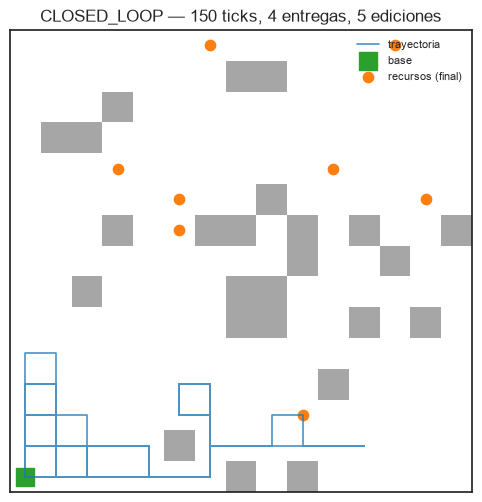

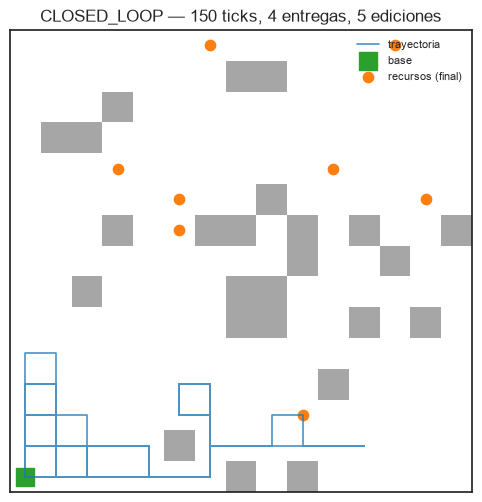

In [2]:
an.fig_trayectoria(policy="CLOSED_LOOP", lambda_dinamismo=0.25, pasos=150)

## 3. Controles de sanidad

Ninguna figura vale nada si el modelo no supera antes los tres controles falsables de
[`docs/02-design.md`](docs/02-design.md) §9. Se miran primero, y a propósito: son
predicciones hechas *antes* de ver los datos.

1. **λ=0 ⇒ `CLOSED_LOOP` = `OPEN_LOOP`.** Sin dinamismo el plan inicial nunca caduca, así que
   replanificar no puede ayudar. Si ayuda, hay un error.
2. **c=0, p=1, r=∞ ⇒ `CLOSED_LOOP` domina en todo λ.** Si deliberar es gratis, el
   replanificador es perfecto y el agente lo ve todo, más deliberación no puede perjudicar.
   Las tres condiciones hacen falta a la vez.
3. **p=0.5, c=10, λ bajo ⇒ `CLOSED_LOOP` peor.** Un replanificador mediocre y caro destruye un
   plan correcto. Si no aparece, el modelo de costo no muerde.

In [3]:
an.controles()

,control,esperado,observado,estado
0,1. λ=0 ⇒ CLOSED_LOOP = OPEN_LOOP,igualdad exacta,93.3 vs 93.3,PASA
1,"2. c=0, p=1, r=∞ ⇒ CLOSED_LOOP domina en todo λ",CLOSED_LOOP ≥ OPEN_LOOP,Δ mínimo sobre λ = +0.0,PASA
2,"3. p=0.5, c=10, λ bajo ⇒ CLOSED_LOOP peor",CLOSED_LOOP < OPEN_LOOP,87.7 vs 102.8,PASA


## 4. La frontera de fase

La figura central: utilidad neta contra dinamismo λ, una línea por política, un panel por
costo de edición `c`. Competencia del oráculo `p=0.9`, radio `r=3`, 30 réplicas por
combinación (3.600 corridas). La banda es el error estándar de la media.

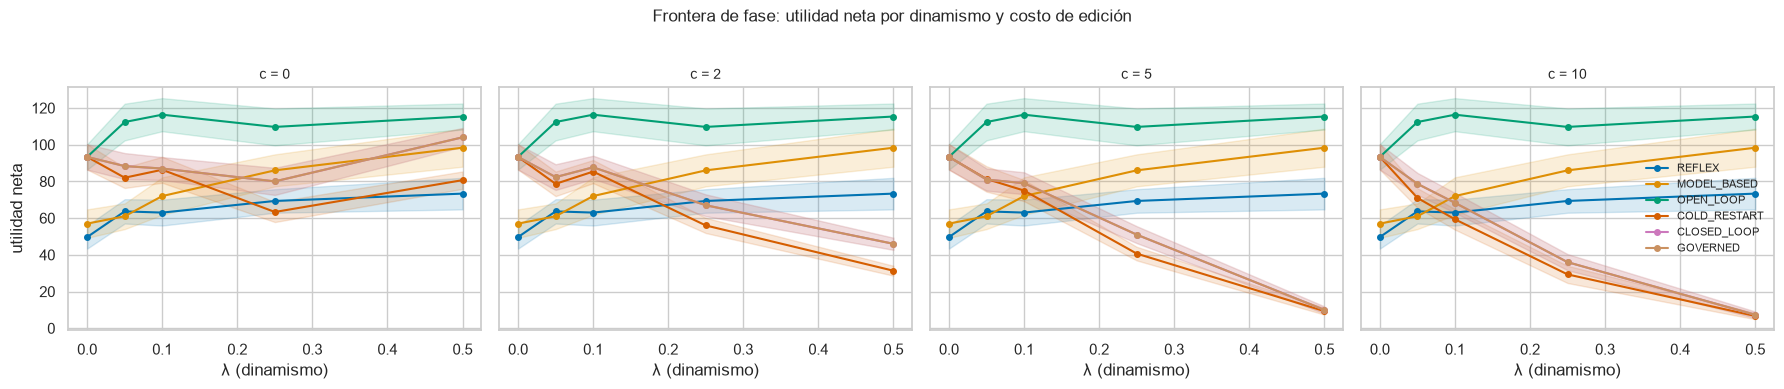

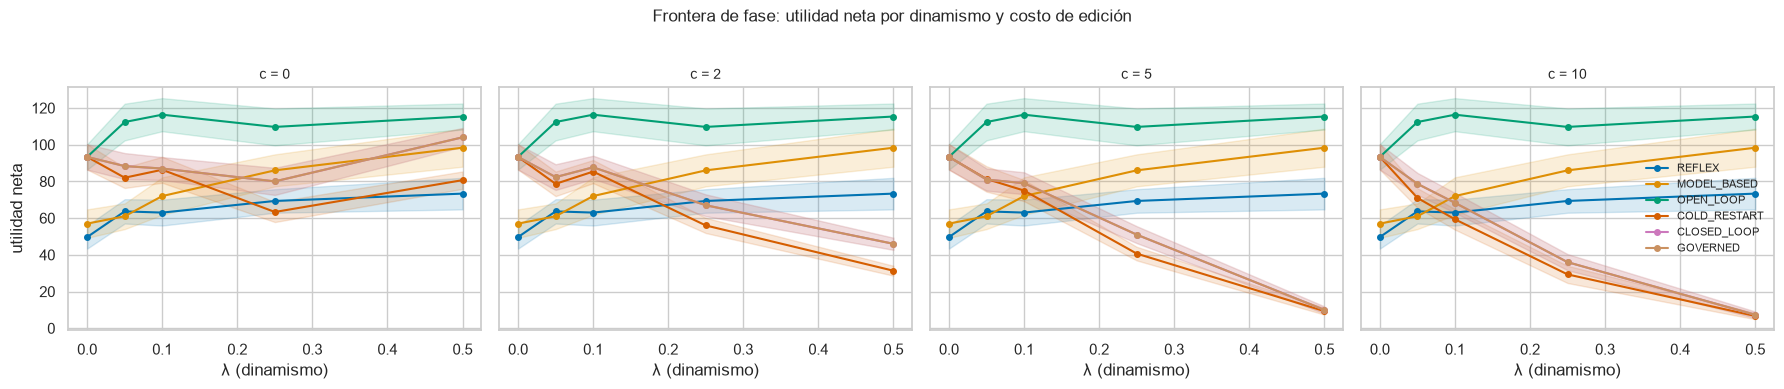

In [4]:
an.fig_frontera()

**Lectura.**

**El resultado que el diseño no anticipaba: con `r=3`, `OPEN_LOOP` domina a todas las
políticas que replanifican, en todo λ y todo `c`** (116 contra 80 de utilidad media a λ=0.1).
No es un fallo del modelo — es el control 2 leído al revés. Con observabilidad parcial el
oráculo repara sobre una creencia obsoleta: casi nunca observa dónde está *realmente* el
objetivo, así que cambia de objetivo cada vez que mira. **Replanificar con mala información es
peor que comprometerse con el plan**, incluso con deliberación gratuita (panel `c=0`).

Lo segundo: el costo de edición `c` no mueve a `OPEN_LOOP` —que no delibera— pero hunde a
`COLD_RESTART` y `CLOSED_LOOP` a medida que crece, y el hundimiento se acelera con λ. Esa es
la frontera que buscaba la pregunta del trabajo.

Y un matiz sobre la taxonomía de R&N: **su orden depende del entorno de tarea**. `REFLEX` es
el peor con λ=0, pero mejora monótonamente con el dinamismo y a λ=0.5 supera a todo lo que
replanifica. Planificar compra previsión y vende oportunismo; cuál de las dos vale más es una
propiedad del entorno, no del agente.

> `CLOSED_LOOP` y `GOVERNED` se superponen exactamente en esta figura, y debe ser así: el
> barrido principal no fija `presupuesto`, y sin presupuesto `GOVERNED` **es** `CLOSED_LOOP`.
> La comparación real entre ambas está en §7.

## 5. Cuánto vale implementar `run=hot`

`COLD_RESTART` es lo que OASys hace hoy: la edición aplica en la corrida siguiente y el
trabajo en vuelo se pierde. `CLOSED_LOOP` es `run=hot`: la edición aplica en sitio. La
diferencia entre ambas es el número que vuelve al sistema real.

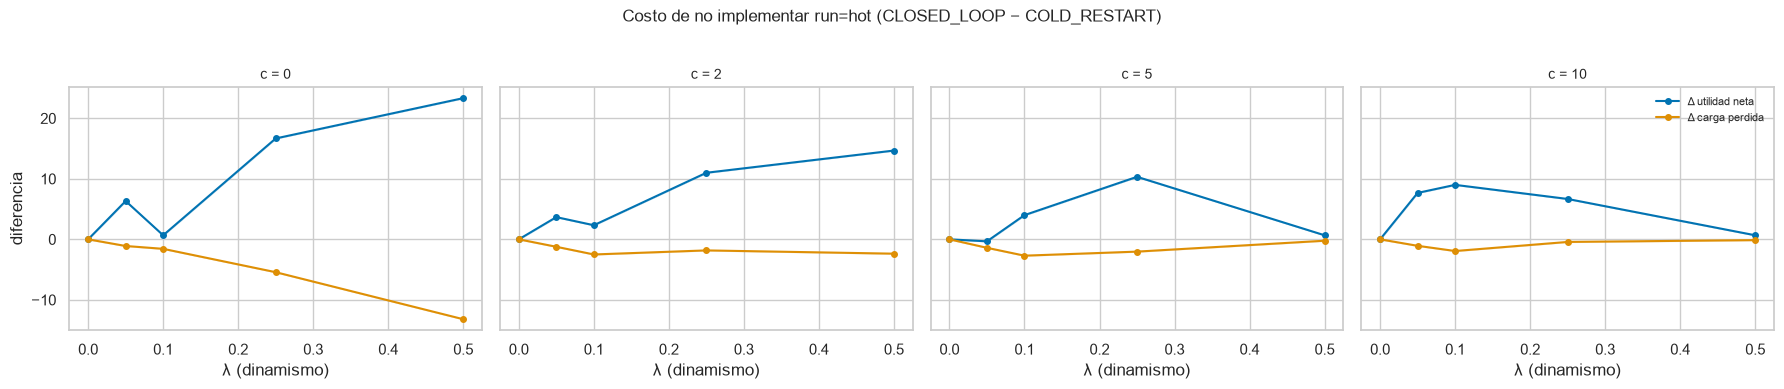

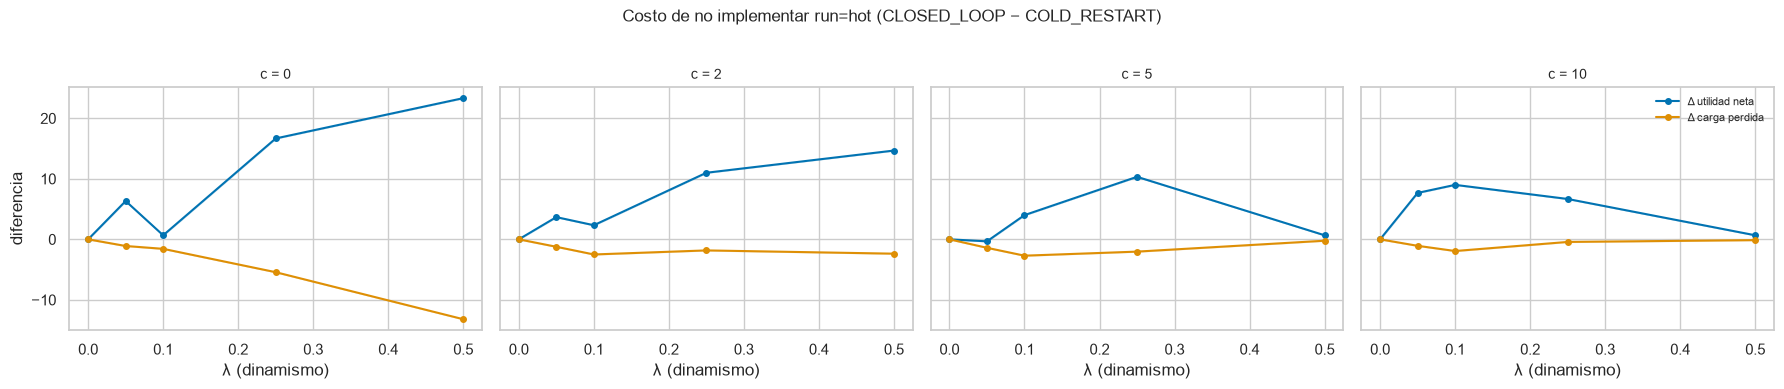

In [5]:
an.fig_hot_vs_cold()

In [6]:
an.delta_hot_vs_cold().query("lambda_dinamismo >= 0.25")

,lambda_dinamismo,costo_edicion,delta_utilidad_neta,delta_carga_perdida,delta_entregas,delta_utilidad_pct
12,0.25,0,16.67,-5.43,1.67,26.32
13,0.25,2,11.00,-1.83,1.10,19.64
14,0.25,5,10.33,-2.03,1.03,25.41
15,0.25,10,6.67,-0.43,0.67,22.73
16,0.50,0,23.33,-13.20,2.33,28.93
17,0.50,2,14.67,-2.37,1.47,46.81
18,0.50,5,0.67,-0.23,0.07,7.14
19,0.50,10,0.67,-0.13,0.07,10.00


**Lectura.** La ventaja de `hot` sobre `cold` es cero en un entorno estático y crece con el
dinamismo: **+29 % de utilidad a λ=0.5 con deliberación gratuita**, sostenida por la caída de
`carga_perdida` —los recursos que un reinicio en frío suelta— de hasta 13 unidades por
corrida. Con `c` alto la ventaja se comprime, porque entonces las dos políticas pagan
deliberación y lo que las separa es solo el trabajo en vuelo.

Traducido a la decisión de ingeniería: **implementar `run=hot` solo se paga en entornos que
cambian rápido y con deliberación barata.** En un entorno casi estático, el snapshot no cuesta
nada y el trabajo de implementarlo no tiene retorno.

## 6. ¿Desde qué competencia conviene auto-editarse?

`p` es la probabilidad de que la edición del oráculo sea la reparación óptima. El fallo no es
ruido: es **plausible y equivocado** —objetivo obsoleto, o ruta con desvío— porque es lo que
un LLM comete de verdad.

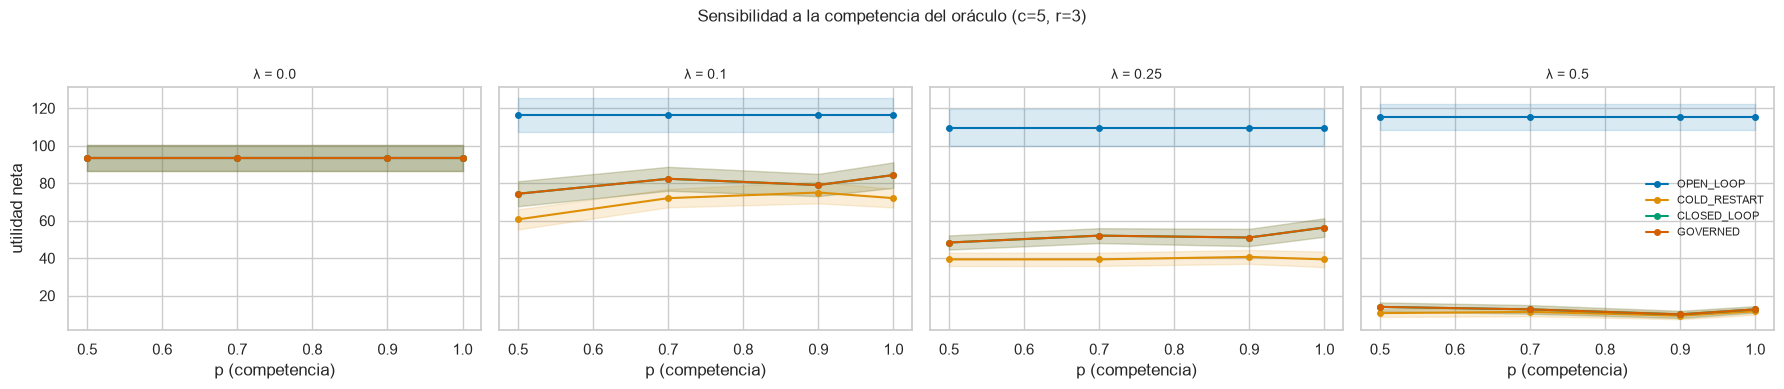

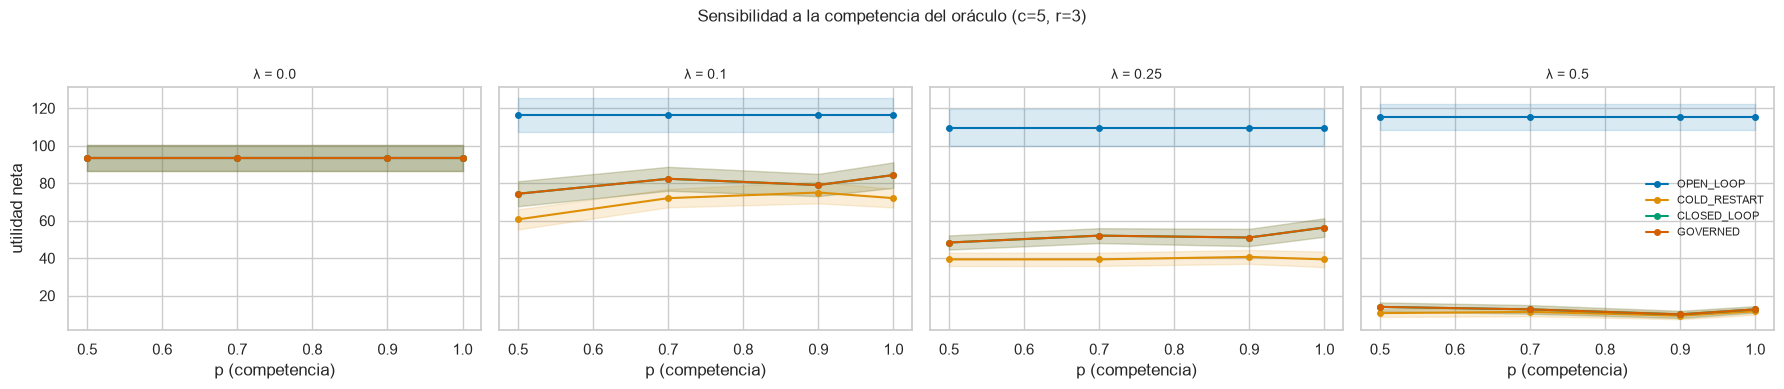

In [7]:
an.fig_competencia()

**Lectura.** La pendiente en `p` existe pero es floja: entre `p=0.5` y `p=1.0` a λ=0.25,
`CLOSED_LOOP` pasa de 48.3 a 56.3 — y `OPEN_LOOP`, que no depende de `p`, se queda en 109.7
por encima de todas. **Mejorar el modelo no rescata la replanificación bajo observabilidad
parcial.** El cuello de botella no es la calidad del reparador sino la calidad de la
información con la que repara, y eso es lo que mide la sección siguiente.

Consecuencia para OASys: subir de modelo no es la palanca. Ampliar lo que el agente ve, sí.

## 7. Observabilidad: el set `ignore`

En OASys cada agente ve solo las páginas que su set `ignore` no oculta. Aquí es el radio `r`.
La métrica que importa no es *si* el agente se entera de una divergencia sino **cuándo**: el
plan lo lleva justo a la celda donde creía que estaba el recurso, así que tarde o temprano lo
descubre — mientras tanto camina hacia el sitio equivocado.

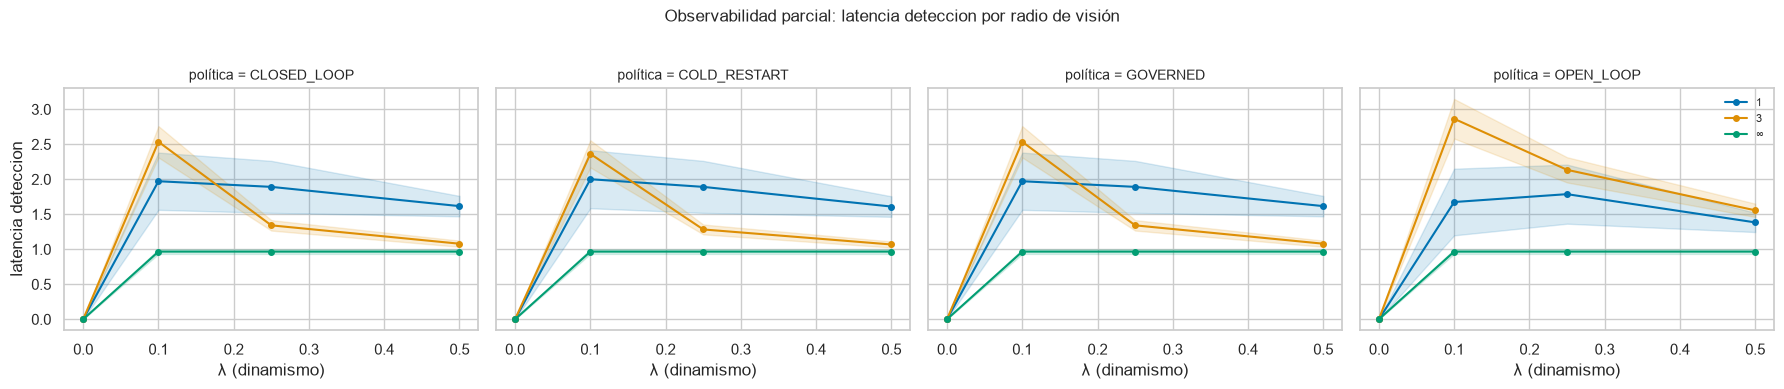

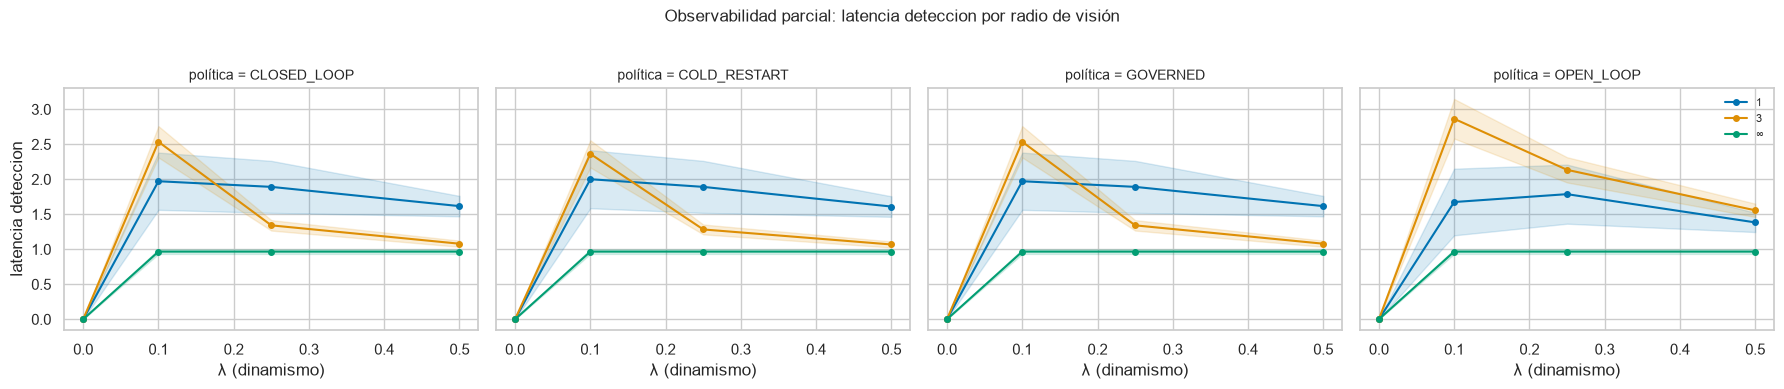

In [8]:
an.fig_observabilidad("latencia_deteccion")

In [9]:
o = an.cargar("observabilidad")
o.groupby("radio")[["latencia_deteccion", "ceguera", "n_ediciones", "utilidad_neta"]].mean().round(2)

,latencia_deteccion,ceguera,n_ediciones,utilidad_neta
radio,,,,
1,1.33,0.03,0.79,46.94
3,1.32,0.02,4.62,69.98
∞,0.72,0.00,8.13,144.69


**Lectura.** La ceguera es casi nula en todos los radios (≤3 %), justo como predecía el
diseño: no se pierden divergencias, se detectan tarde. La latencia casi se duplica al pasar de
`r=∞` a `r=1` (0.72 → 1.33 ticks), y la utilidad se desploma de **144.7 a 46.9**.

Ese salto es el resultado más grande del trabajo y explica el de la §4: con `r=∞` la
replanificación funciona —es el control 2, que pasa— y con `r=3` deja de funcionar. **La
observabilidad, no la competencia del oráculo ni el costo de edición, es la variable que
decide si auto-editarse ayuda.**

## 8. Gobernanza: acotar las ediciones

`GOVERNED` es `run=hot` con un presupuesto de `B` ediciones y líneas `@lock` que el oráculo no
puede tocar — el análogo de `validate_edit` en `governance.rs`. `CLOSED_LOOP` no tiene
presupuesto, así que aparece como una recta horizontal de referencia.

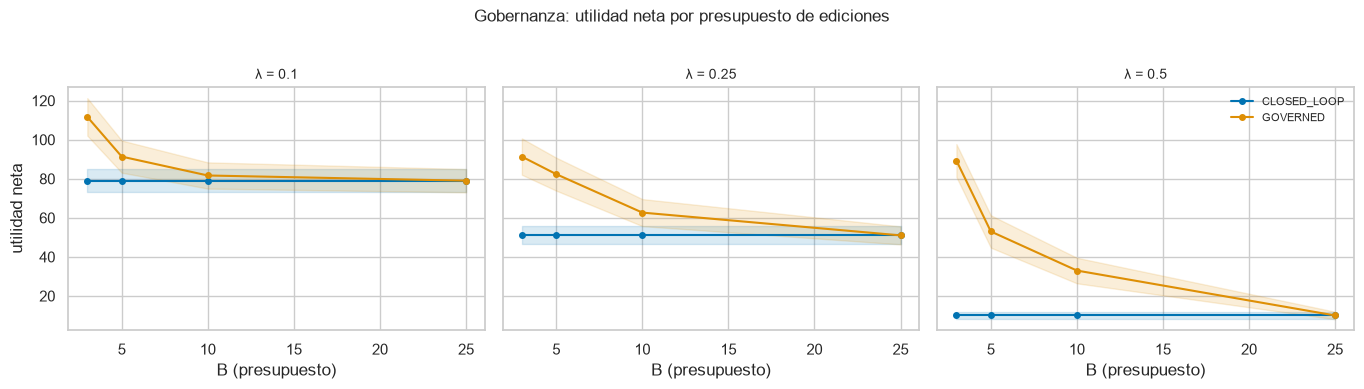

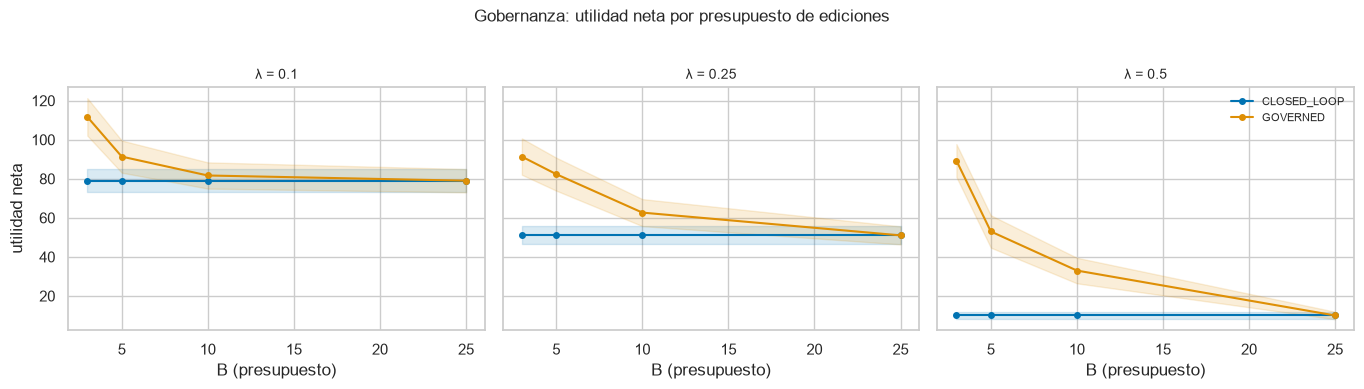

In [10]:
an.fig_gobernanza("utilidad_neta")

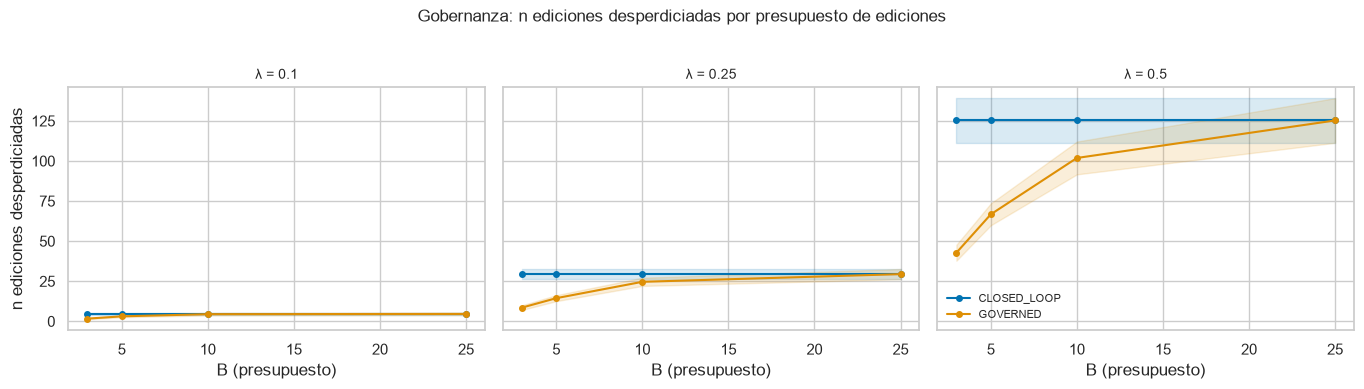

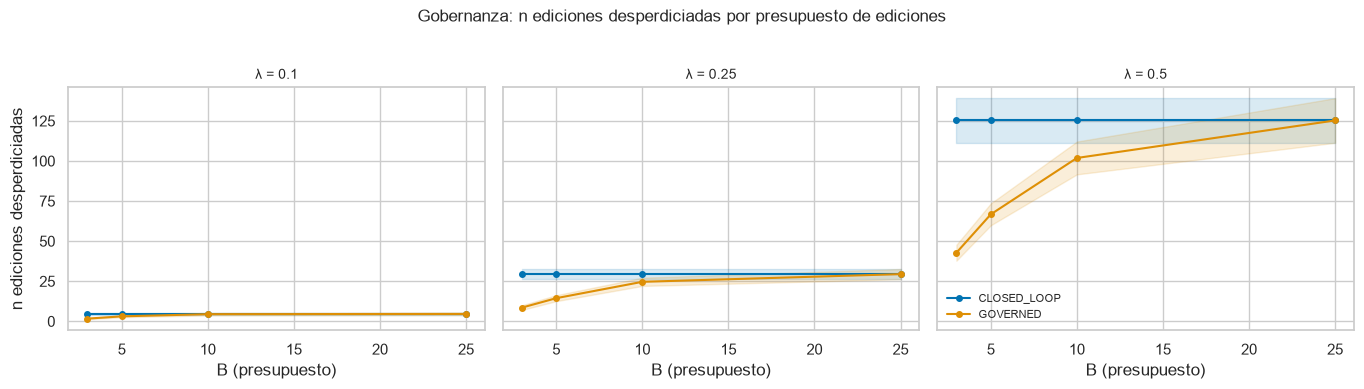

In [11]:
an.fig_gobernanza("n_ediciones_desperdiciadas")

**Lectura.** El presupuesto no es una salvaguarda menor: **es la diferencia entre funcionar y
no funcionar.** A λ=0.5, `GOVERNED` con `B=3` rinde **89.3** contra **10.0** de `CLOSED_LOOP`
sin acotar — casi nueve veces —, y las ediciones desperdiciadas caen de 125.3 a 42.8. A medida
que `B` crece, `GOVERNED` converge monótonamente a `CLOSED_LOOP` y en `B=25` son la misma
política, que es exactamente lo que debe pasar.

Es decir: **el thrashing de replanificación es real, y una cuota pequeña lo corta.** Y la cuota
óptima es *pequeña* — más chica que las que uno pondría por intuición.

Aquí es donde el trabajo vuelve al sistema real. `MAX_ITER = 5` en OASys era un número puesto a
dedo; este barrido dice que un tope bajo no es una limitación que haya que quitar sino la
razón por la que el sistema funciona. Lo que falta en OASys no es subirlo: es **derivarlo del
dinamismo del entorno** en vez de fijarlo.

## 9. Conclusiones

1. **La observabilidad domina todo lo demás.** Con visión total la replanificación gana (144.7
   contra 46.9 con `r=1`); con `r=3` pierde contra el lazo abierto en todo λ y todo `c`. El set
   `ignore` de OASys no es una decisión de privacidad: es la variable que decide si la
   capacidad central del sistema ayuda o estorba.
2. **Mejorar el reparador no rescata nada.** Subir `p` de 0.5 a 1.0 mueve la utilidad ocho
   puntos; el lazo abierto sigue cincuenta por encima. El cuello de botella es la información,
   no el modelo.
3. **`run=hot` vale entre 0 % y 29 %,** creciendo con el dinamismo y decreciendo con el costo
   de deliberación. En entornos casi estáticos implementarlo no tiene retorno.
4. **Acotar las ediciones multiplica el rendimiento por nueve** en régimen dinámico. `MAX_ITER
   = 5` acertó por accidente; lo que falta es derivarlo.
5. **El orden de la taxonomía de R&N depende del entorno de tarea.** El agente reflejo, el peor
   con λ=0, supera a todo lo que planifica a λ=0.5. Planificar compra previsión y vende
   oportunismo.

### Límites

- Un solo agente, retícula 15×15, `T_max=400`. El régimen multi-agente queda fuera.
- `κ=0` en todos los barridos: el único castigo por deliberar es el tiempo perdido, no el
  costo en tokens. Con `κ>0` la frontera se desplaza y no se ha medido.
- El oráculo es una abstracción del LLM con dos modos de fallo. Es fiel al *tipo* de error,
  no a su distribución real.

## Reproducir

```bash
uv run pytest project/oasys_abm/tests/                                   # 67 tests
PYTHONPATH=project uv run python -m oasys_abm.experiments --full --procesos 0
PYTHONPATH=project uv run python -m oasys_abm.analysis --controles --figuras
```

Para explorar de forma interactiva, todas las figuras aceptan el otro backend:

```python
an.fig_frontera(backend="plotly")   # o an.BACKEND = "plotly" para todas
```